In [298]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import (
    plot_lines, plot_eer, plot_f1, plot_pareto, plot_loss_curves, plot_loss_vs_eer,
    plot_gmm_components, plot_gmm_diag_vs_full, _filter,
)

# df = pd.read_parquet(ROOT / "results" / "sweep.parquet.correct")
# df = pd.read_parquet(ROOT / "results" / "sweep_pendigits.parquet")
df = pd.read_parquet(ROOT / "results" / "sweep_speech_latest.parquet")

# Train_n value for plots that pin to a single budget
FIXED_TRAIN_N = 10


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Slide 1: GMM-only comparison

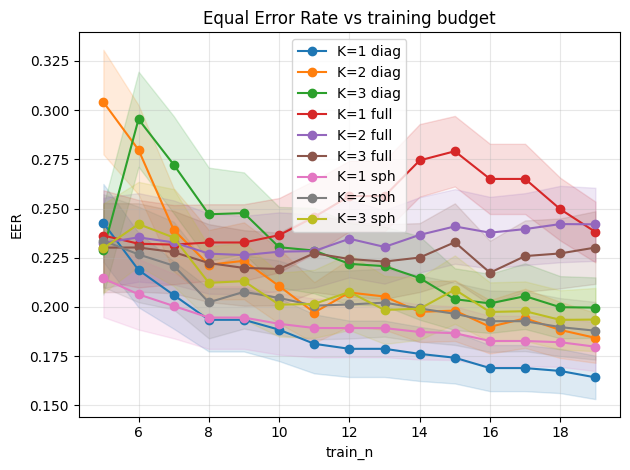

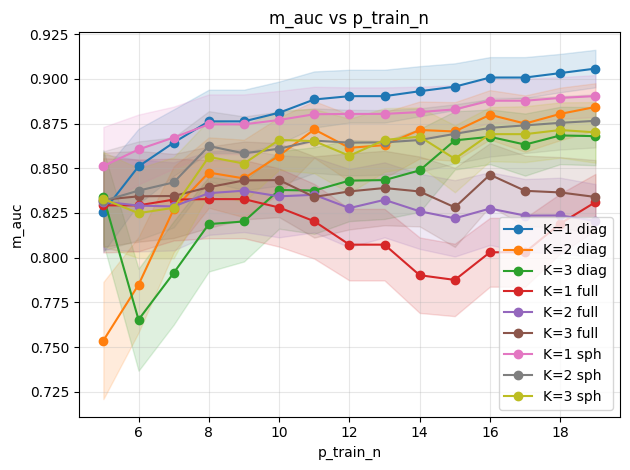

In [299]:
gmm_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 1b: GMM covariance type comparison

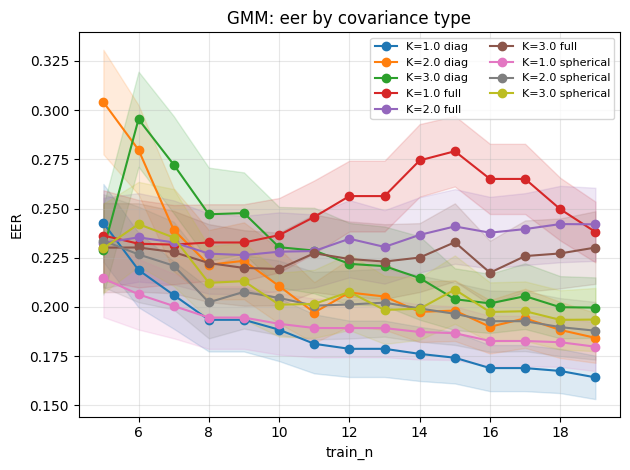

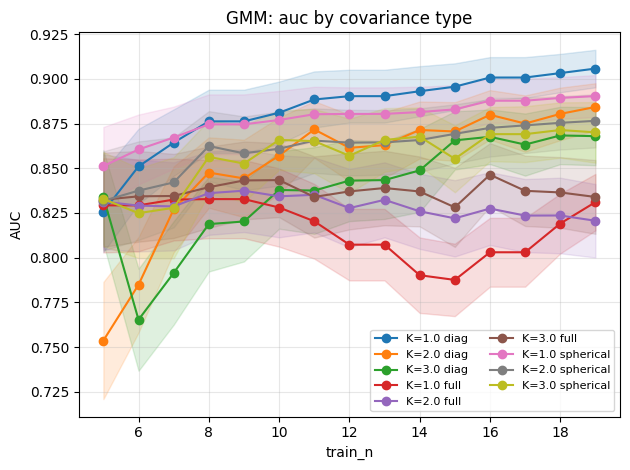

In [300]:
plot_gmm_diag_vs_full(df, y="m_eer")
plot_gmm_diag_vs_full(df, y="m_auc")
plt.show()

# Slide 1c: GMM optimal K

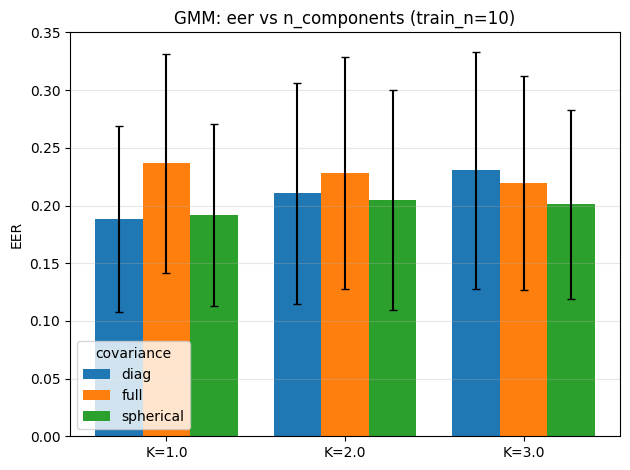

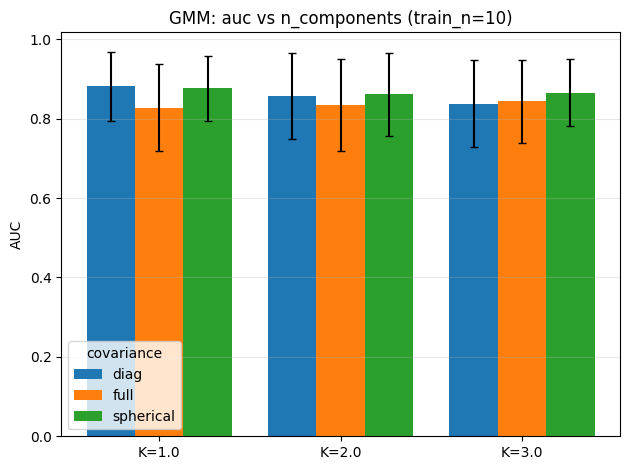

In [301]:
plot_gmm_components(df, y="m_eer", fixed_train_n=FIXED_TRAIN_N)
plot_gmm_components(df, y="m_auc", fixed_train_n=FIXED_TRAIN_N)
plt.show()

# Slide 1c-ci: GMM EER and AUC at fixed train_n with 95% CI

Horizontal error-bar plot of GMM configs' EER and AUC at a fixed `train_n`, with 95% confidence intervals across trials x target words.

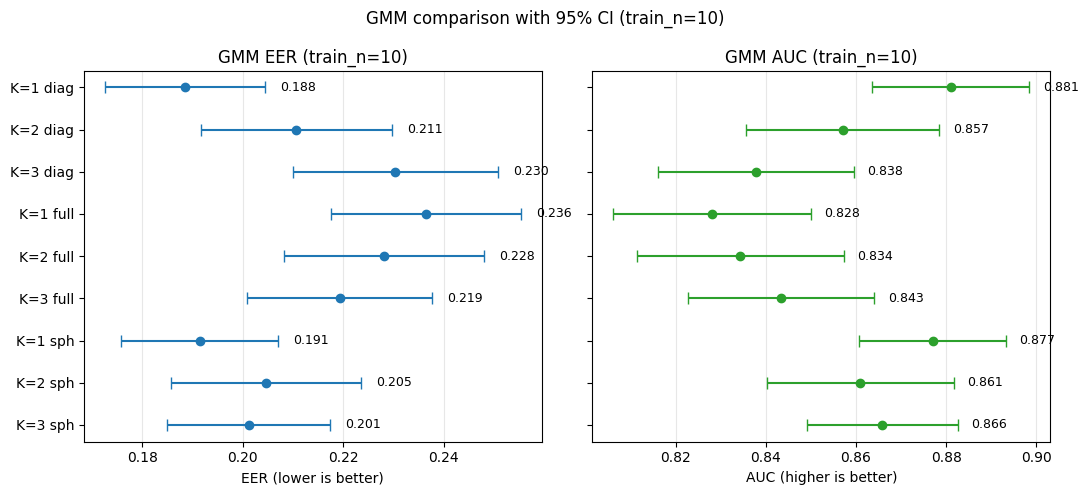

In [302]:
from scipy import stats as _stats
import numpy as np

GMM_CI_TRAIN_N = FIXED_TRAIN_N

gmm_ci_configs = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

sub_gmm_ci = df[df["p_train_n"] == GMM_CI_TRAIN_N]

def _mean_ci95(vals):
    vals = vals.dropna()
    n = len(vals)
    if n < 2:
        return (vals.mean() if n else float("nan"), 0.0)
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    return vals.mean(), t_crit * sem

fig, (ax_eer, ax_auc) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for i, (label, where) in enumerate(gmm_ci_configs):
    s = _filter(sub_gmm_ci, where)
    if s.empty:
        continue
    m_eer, ci_eer = _mean_ci95(s["m_eer"])
    m_auc, ci_auc = _mean_ci95(s["m_auc"])
    ax_eer.errorbar(m_eer, i, xerr=ci_eer, fmt="o", color="tab:blue", capsize=4)
    ax_eer.text(m_eer + ci_eer + 0.003, i, f"{m_eer:.3f}", va="center", fontsize=9)
    ax_auc.errorbar(m_auc, i, xerr=ci_auc, fmt="o", color="tab:green", capsize=4)
    ax_auc.text(m_auc + ci_auc + 0.003, i, f"{m_auc:.3f}", va="center", fontsize=9)

ax_eer.set_yticks(range(len(gmm_ci_configs)))
ax_eer.set_yticklabels([c[0] for c in gmm_ci_configs])
ax_eer.set_xlabel("EER (lower is better)")
ax_eer.set_title(f"GMM EER (train_n={GMM_CI_TRAIN_N})")
ax_eer.invert_yaxis()
ax_eer.grid(axis="x", alpha=0.3)

ax_auc.set_xlabel("AUC (higher is better)")
ax_auc.set_title(f"GMM AUC (train_n={GMM_CI_TRAIN_N})")
ax_auc.grid(axis="x", alpha=0.3)

fig.suptitle(f"GMM comparison with 95% CI (train_n={GMM_CI_TRAIN_N})")
fig.tight_layout()
plt.show()


# Slide 1d: GMM EER per target word (by covariance type)

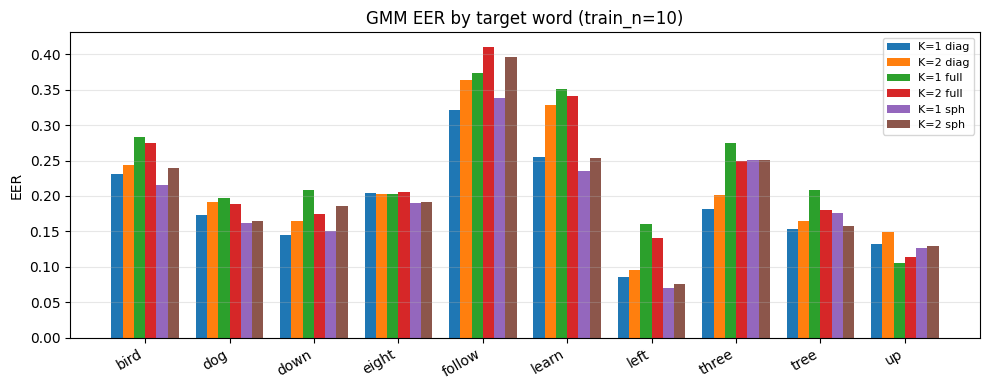

In [303]:
gmm_word_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
]

fixed_train_n = FIXED_TRAIN_N
sub = df[df["p_train_n"] == fixed_train_n]
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(gmm_word_lines)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, where) in enumerate(gmm_word_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(gmm_word_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"GMM EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 1e: Statistical significance (paired t-tests)

In [304]:
import numpy as np
from scipy import stats

TRAIN_N = FIXED_TRAIN_N
sub = df[df["p_train_n"] == TRAIN_N]
idx = ["p_trial", "p_target_class"]

def paired_test(a_eer, b_eer):
    """Return (n, mean_diff, cohen_d, t, p) for b - a."""
    paired = pd.concat([a_eer.rename("a"), b_eer.rename("b")], axis=1).dropna()
    diff = paired["b"] - paired["a"]
    d = diff.mean() / diff.std()
    t, p = stats.ttest_rel(paired["b"], paired["a"])
    return len(paired), diff.mean(), d, t, p

def get_eer(where: dict):
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        if k not in sub.columns:
            return pd.Series(dtype=float)  # column absent: treat as no matching rows
        mask &= sub[k] == v
    return sub[mask].set_index(idx)["m_eer"]

# Define all configs to compare
configs = {
    "GMM K=1 diag": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"},
    "GMM K=2 diag": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"},
    "GMM K=3 diag": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"},
    "GMM K=1 full": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"},
    "GMM K=2 full": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"},
    "GMM K=3 full": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"},
    "GMM K=1 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"},
    "GMM K=2 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"},
    "GMM K=3 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"},
    "SmallAE": {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100},
    "kNN k=1":  {"p_adapter": "KNNAdapter", "p_k": 1},
    "kNN k=2":  {"p_adapter": "KNNAdapter", "p_k": 2},
    "kNN k=3":  {"p_adapter": "KNNAdapter", "p_k": 3},
    "kNN k=4":  {"p_adapter": "KNNAdapter", "p_k": 4},
    "kNN k=5":  {"p_adapter": "KNNAdapter", "p_k": 5},
    "kNN k=6":  {"p_adapter": "KNNAdapter", "p_k": 6},
    "kNN k=7":  {"p_adapter": "KNNAdapter", "p_k": 7},
    "kNN k=8":  {"p_adapter": "KNNAdapter", "p_k": 8},
    "kNN k=9":  {"p_adapter": "KNNAdapter", "p_k": 9},
    "kNN k=10": {"p_adapter": "KNNAdapter", "p_k": 10},
}

# All pairwise comparisons
config_names = list(configs.keys())
rows = []
for i in range(len(config_names)):
    for j in range(i + 1, len(config_names)):
        a_name, b_name = config_names[i], config_names[j]
        a_eer = get_eer(configs[a_name])
        b_eer = get_eer(configs[b_name])
        if a_eer.empty or b_eer.empty:
            continue
        n, md, d, t, p = paired_test(a_eer, b_eer)
        rows.append({"A": a_name, "B": b_name, "n_pairs": n,
                      "mean_diff": md, "cohen_d": d, "t_stat": t, "p_value": p})

if rows:
    res = pd.DataFrame(rows)
    res["sig"] = res["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
    print(f"Paired t-tests on EER at train_n={TRAIN_N}  (is A better than B?)\n")
    print(res.to_string(index=False, float_format="%.4f"))
else:
    print(f"No matching config pairs found in data at train_n={TRAIN_N}."
          " Re-run the sweep with the configs above.")

Paired t-tests on EER at train_n=10  (is A better than B?)

           A            B  n_pairs  mean_diff  cohen_d  t_stat  p_value sig
GMM K=1 diag GMM K=2 diag      100     0.0222   0.4519  4.5191   0.0000 ***
GMM K=1 diag GMM K=3 diag      100     0.0419   0.5597  5.5968   0.0000 ***
GMM K=1 diag GMM K=1 full      100     0.0480   0.8043  8.0429   0.0000 ***
GMM K=1 diag GMM K=2 full      100     0.0396   0.6395  6.3955   0.0000 ***
GMM K=1 diag GMM K=3 full      100     0.0309   0.5746  5.7457   0.0000 ***
GMM K=1 diag  GMM K=1 sph      100     0.0030   0.0755  0.7549   0.4521  ns
GMM K=1 diag  GMM K=2 sph      100     0.0161   0.2989  2.9889   0.0035  **
GMM K=1 diag  GMM K=3 sph      100     0.0127   0.2165  2.1652   0.0328   *
GMM K=1 diag      kNN k=1      100     0.0145   0.2807  2.8071   0.0060  **
GMM K=1 diag      kNN k=2      100     0.0038   0.0750  0.7499   0.4551  ns
GMM K=1 diag      kNN k=3      100    -0.0023  -0.0436 -0.4359   0.6639  ns
GMM K=1 diag      kNN k=4   

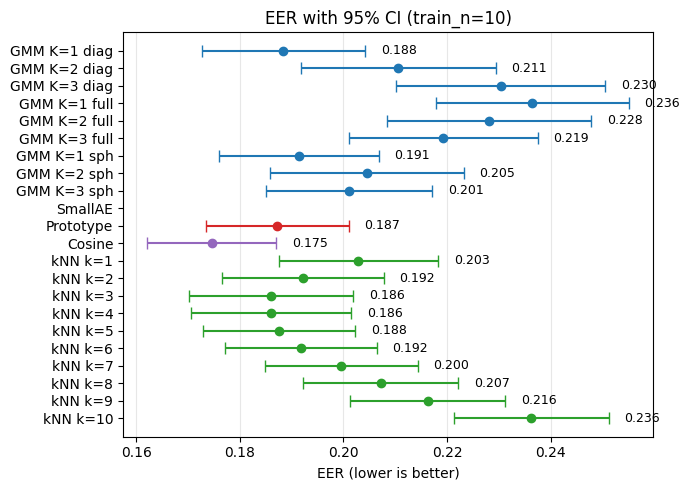

In [305]:
# 95% CI plot for EER at train_n=TRAIN_N (defined in previous cell)
ci_configs = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",  {"p_adapter": "KNNAdapter", "p_k": 2}),
    ("kNN k=3",  {"p_adapter": "KNNAdapter", "p_k": 3}),
    ("kNN k=4",  {"p_adapter": "KNNAdapter", "p_k": 4}),
    ("kNN k=5",  {"p_adapter": "KNNAdapter", "p_k": 5}),
    ("kNN k=6",  {"p_adapter": "KNNAdapter", "p_k": 6}),
    ("kNN k=7",  {"p_adapter": "KNNAdapter", "p_k": 7}),
    ("kNN k=8",  {"p_adapter": "KNNAdapter", "p_k": 8}),
    ("kNN k=9",  {"p_adapter": "KNNAdapter", "p_k": 9}),
    ("kNN k=10", {"p_adapter": "KNNAdapter", "p_k": 10}),
]

colors = {
    "GMMAdapter": "tab:blue",
    "SmallAEAdapter": "tab:orange",
    "KNNAdapter": "tab:green",
    "PrototypeAdapter": "tab:red",
    "CosineAdapter": "tab:purple",
}

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, where) in enumerate(ci_configs):
    if any(k not in sub.columns for k in where):
        continue  # config references a column not present in current results
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        mask &= sub[k] == v
    vals = sub[mask]["m_eer"]
    if vals.empty:
        continue
    mean = vals.mean()
    ci = 1.96 * vals.std() / np.sqrt(len(vals))
    color = colors[where["p_adapter"]]
    ax.errorbar(mean, i, xerr=ci, fmt="o", color=color, capsize=4)
    ax.text(mean + ci + 0.003, i, f"{mean:.3f}", va="center", fontsize=9)

ax.set_yticks(range(len(ci_configs)))
ax.set_yticklabels([c[0] for c in ci_configs])
ax.set_xlabel("EER (lower is better)")
ax.set_title(f"EER with 95% CI (train_n={TRAIN_N})")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 2: Best GMMs vs SmallAE vs kNN

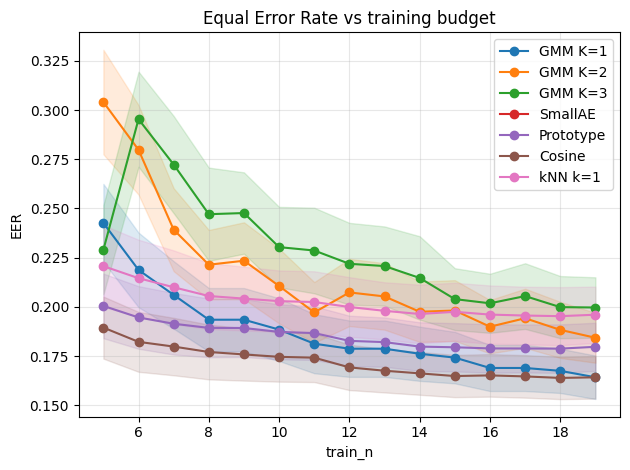

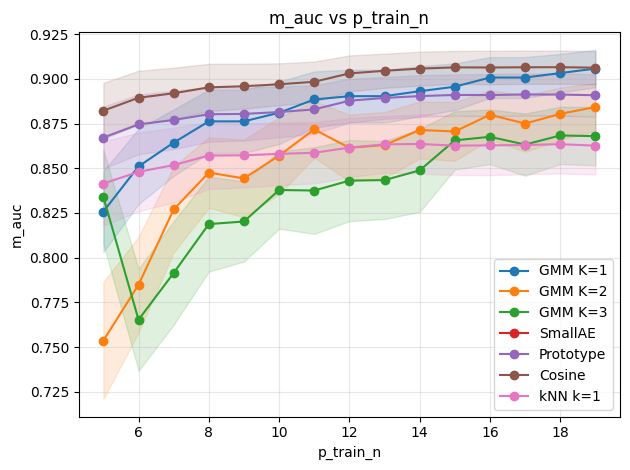

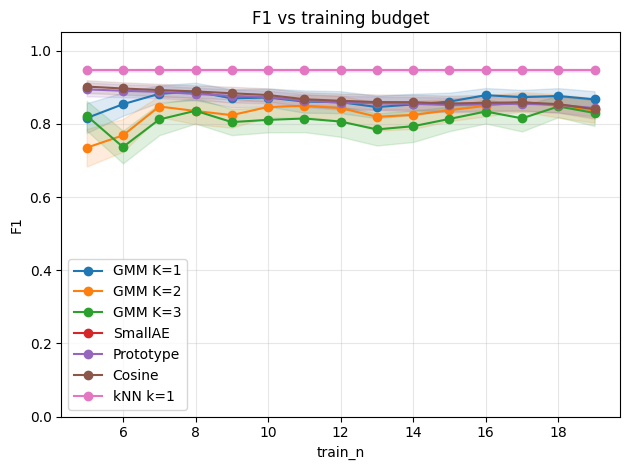

In [306]:
compare_lines = [
    ("GMM K=1",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)


# Slide 3: Training FLOPs comparison

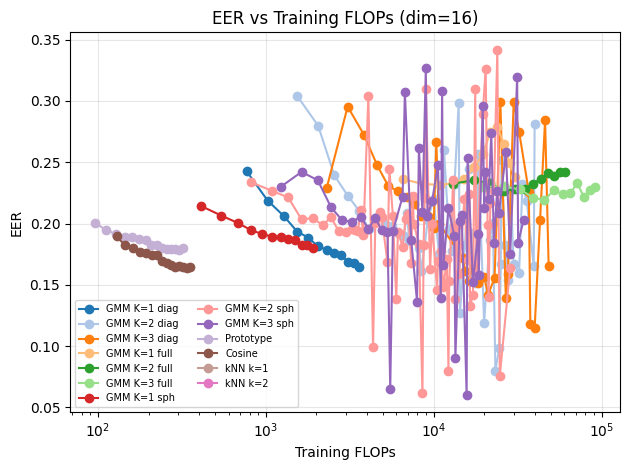

In [307]:
mac_lines = [
    # GMMs -- diag
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),

    # GMMs -- full
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),

    # GMMs -- spherical
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),

    # Simple-prototype baselines
    ("Prototype",    {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",       {"p_adapter": "CosineAdapter"}),

    # kNNs
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",      {"p_adapter": "KNNAdapter", "p_k": 2}),

    # AEs
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
]

from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training FLOPs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 3b: Inference FLOPs comparison

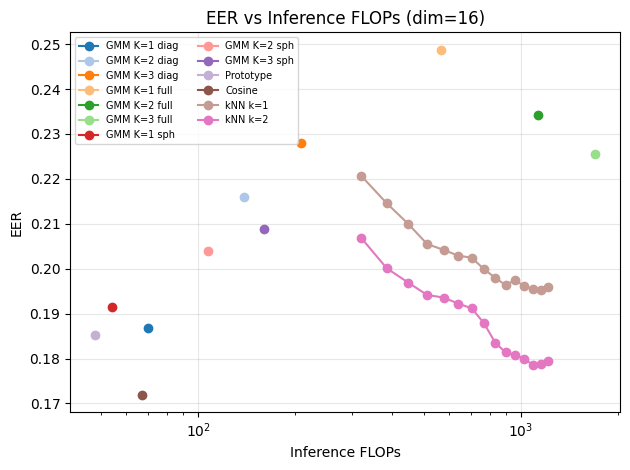

In [308]:
from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 4: FLOPs-fair comparison (low-epoch SmallAE vs GMM)

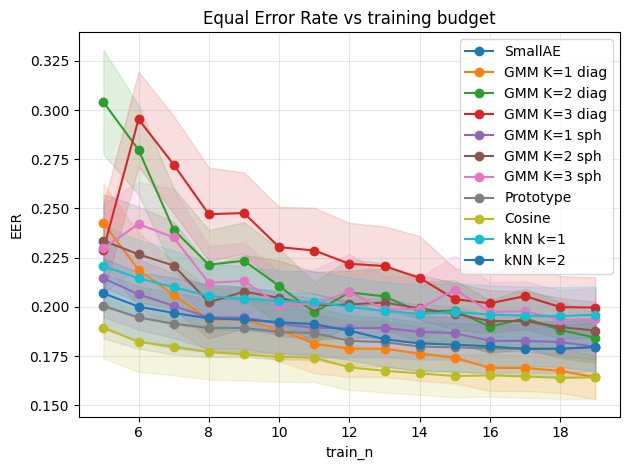

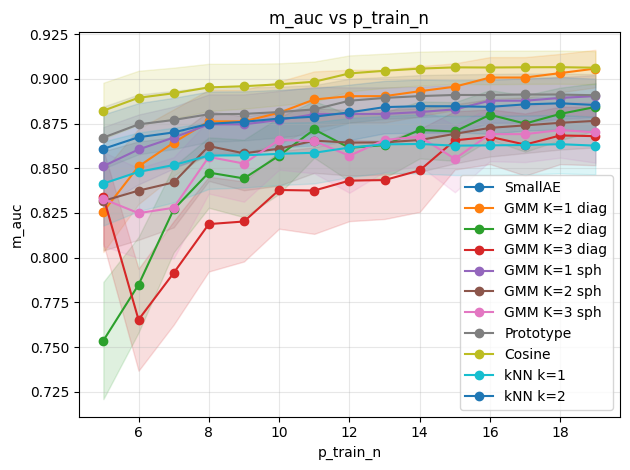

In [309]:
fair_lines = [
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("GMM K=1 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("Prototype",      {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",         {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",        {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",        {"p_adapter": "KNNAdapter", "p_k": 2}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)

# Slide 4b: ACC at FAR=5% vs enrollment budget

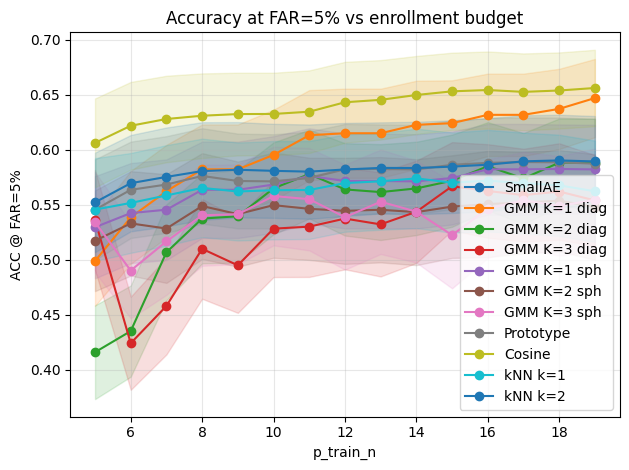

In [310]:
plot_lines(df, x="p_train_n", y="m_acc_at_far5", lines=fair_lines)
plt.ylabel("ACC @ FAR=5%")
plt.title("Accuracy at FAR=5% vs enrollment budget")
plt.show()

# Slide 5: Training FLOPs (low-epoch SmallAE vs GMM)

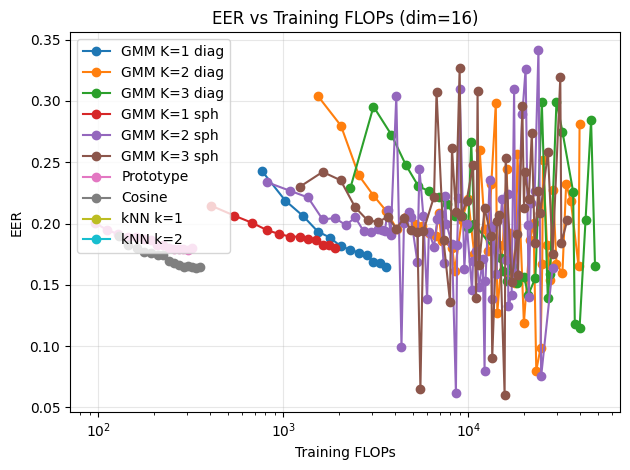

In [311]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 5b: Inference FLOPs (low-epoch SmallAE vs GMM)

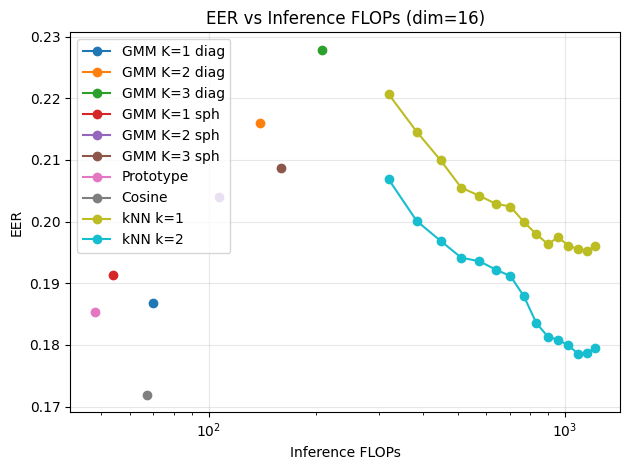

In [312]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 6: EER variance across target words

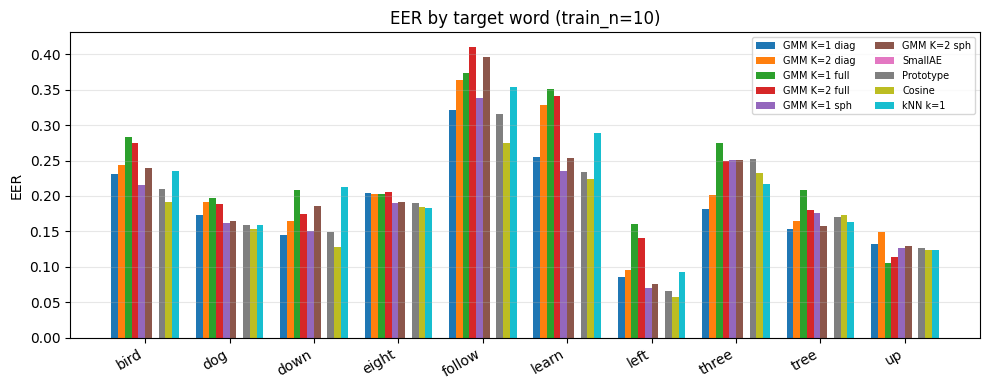

In [313]:
target_lines = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 8, "p_epochs": 100}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN k=1",   {"p_adapter": "KNNAdapter", "p_k": 1}),
]

# EER per target word at fixed train_n -- shows which words are harder to enroll
fixed_train_n = FIXED_TRAIN_N
sub = df[df["p_train_n"] == fixed_train_n]

fig, ax = plt.subplots(figsize=(10, 4))
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(target_lines)
for i, (label, where) in enumerate(target_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(target_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=7, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 7: Pareto frontier — iso-FLOP comparison

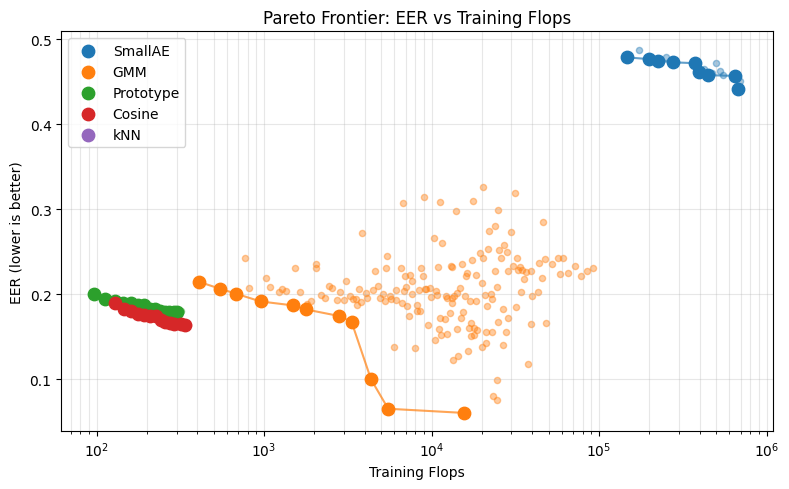

In [314]:
from compare.plots import plot_pareto

pareto_lines = [
    ("SmallAE",   {"p_adapter": "SmallAEAdapter"}),
    ("GMM",       {"p_adapter": "GMMAdapter"}),
    ("Prototype", {"p_adapter": "PrototypeAdapter"}),
    ("Cosine",    {"p_adapter": "CosineAdapter"}),
    ("kNN",       {"p_adapter": "KNNAdapter"}),
]

plot_pareto(df, lines=pareto_lines)
plt.show()

# Slide 7b: Pareto frontier — inference FLOPs

# Slide 8b: threshold_mode — val split vs full-budget training threshold

Does withholding a val split hurt the AE in the micro-data regime?
Compare `threshold_mode=val` (25% held out, threshold on val scores) vs
`threshold_mode=train` (full budget for training, threshold on train scores).

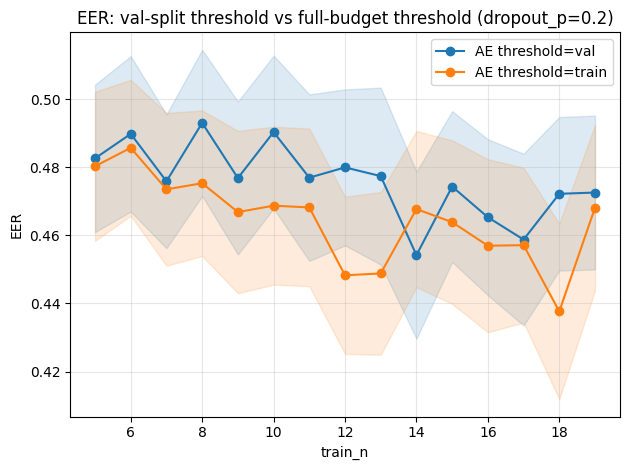

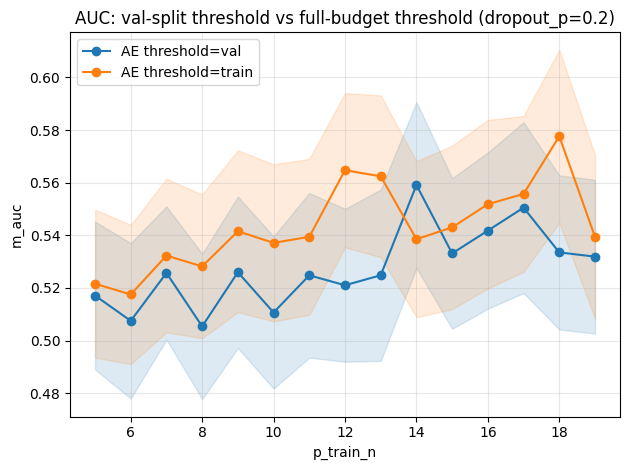

In [315]:
if "p_threshold_mode" not in df.columns:
    print("Skipping threshold_mode ablation: column 'p_threshold_mode' not present in current results.")
else:
    # Threshold-mode ablation: pin dropout_p=0.2 so only threshold_mode varies.
    threshold_lines = [
        ("AE threshold=val",   {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "val"}),
        ("AE threshold=train", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=threshold_lines)
    plt.title("EER: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=threshold_lines)
    plt.title("AUC: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plt.show()

# Slide 8c: dropout — no dropout vs dropout_p=0.2

Does denoising regularisation (dropout during training) help the AE in the micro-data regime?

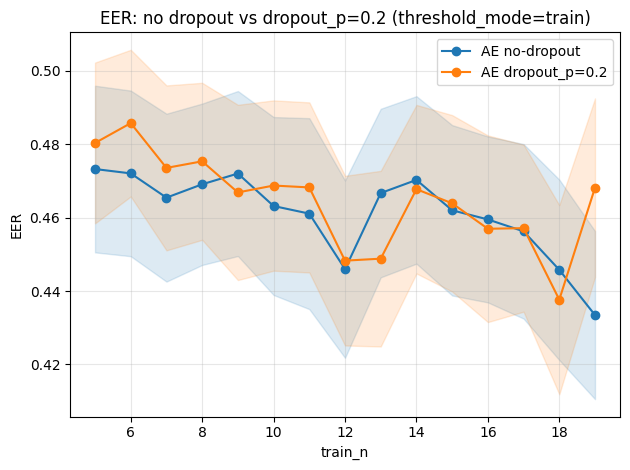

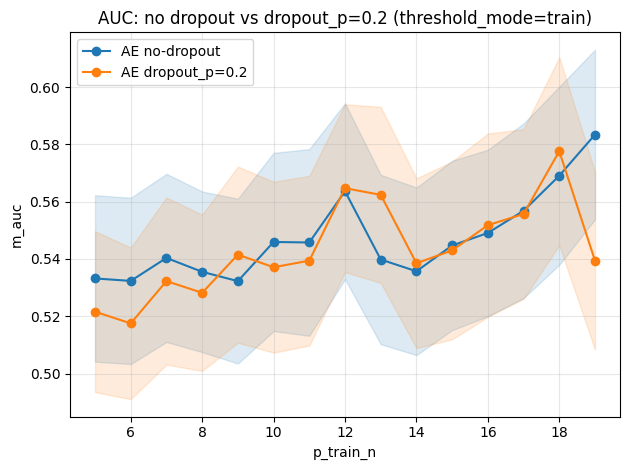

In [316]:
if "p_dropout_p" not in df.columns:
    print("Skipping dropout ablation: column 'p_dropout_p' not present in current results.")
else:
    # Dropout ablation: pin threshold_mode=train so only dropout varies.
    dropout_lines = [
        ("AE no-dropout",    {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.0, "p_threshold_mode": "train"}),
        ("AE dropout_p=0.2", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=dropout_lines)
    plt.title("EER: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=dropout_lines)
    plt.title("AUC: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plt.show()

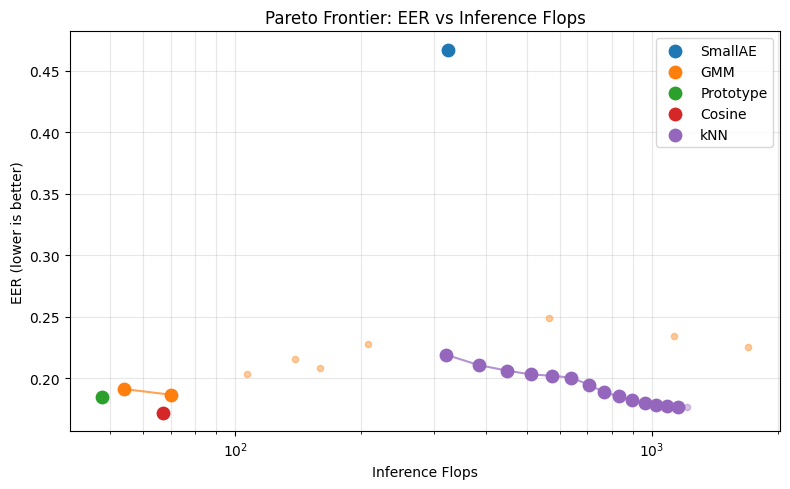

In [317]:
plot_pareto(df, lines=pareto_lines, x="m_inference_flops")
plt.show()

# Slide 8: AE training convergence

TODO: FIXME: the x axis is the percentage of the training wrt the number of iterations.
Make sure to consider this. This should be fixed.

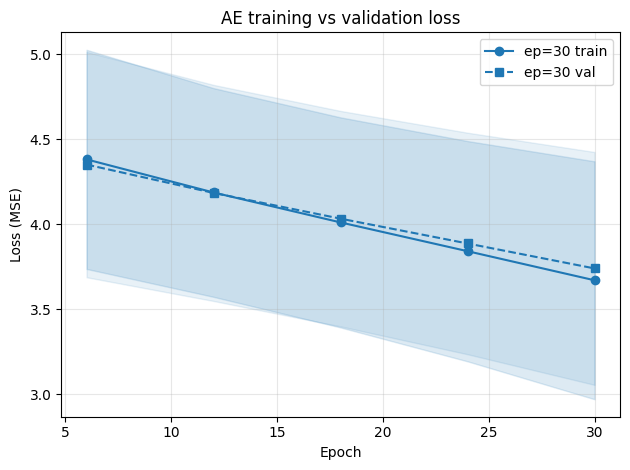

In [318]:
from compare.plots import plot_loss_curves, plot_loss_vs_eer

# Loss curves: is training still improving at the last epoch?
# Each checkpoint is at 20%, 40%, 60%, 80%, 100% of training.
# A line still dropping at x=1.0 means the adapter needs more epochs.
loss_lines = [
    # ("ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    # ("ep=20",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 20}),
    ("ep=30", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30}),
]

plot_loss_curves(df, lines=loss_lines)
plt.show()

# Final test: held-out TEST_WORDS

Results from `python -m src.compare.test_eval` on the 5 reserved test words (`visual, five, seven, no, off`).
Each test word is scored against the other 4 as adversarial.

In [319]:
import numpy as np
# test_df = pd.read_parquet(ROOT / "results" / "test.parquet")        # speech (legacy filename)
# test_df = pd.read_parquet(ROOT / "results" / "test_speech.parquet")  # speech
test_df = pd.read_parquet(ROOT / "results" / "test_pendigits.parquet")
print(f"Loaded {len(test_df)} rows | adapters: {test_df['p_adapter'].unique().tolist()}")
test_df.head()

Loaded 1400 rows | adapters: ['GMMAdapter', 'SmallAEAdapter', 'CosineAdapter', 'PrototypeAdapter', 'KNNAdapter']


,p_split,p_trial,p_embedding_dim,p_target_class,p_other_classes,p_adapter,p_n_components,p_covariance_type,p_train_n,m_recall,...,p_threshold_mode,p_dropout_p,p_device,p_input_dim,m_train_loss_1,m_train_loss_2,m_train_loss_3,m_train_loss_4,m_train_loss_5,p_k
0,test,0,16,7,9,GMMAdapter,1.0,diag,5,0.948,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test,0,16,7,9,GMMAdapter,2.0,spherical,5,1.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,test,0,16,7,9,GMMAdapter,1.0,full,5,1.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,test,0,16,7,9,SmallAEAdapter,NaN,NaN,5,1.000,...,train,0.0,mps,16.0,0.812539,0.785204,0.760422,0.739378,0.72126,NaN
4,test,0,16,7,9,CosineAdapter,NaN,NaN,5,0.396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary metrics (mean +/- std across trials x target words)

In [320]:
metrics = ["m_eer", "m_auc", "m_auprc", "m_f1", "m_acc_at_far5"]
metrics = [m for m in metrics if m in test_df.columns]
summary = test_df.groupby("p_adapter")[metrics].agg(["mean", "std"]).round(4)
summary

m_eer           m_auc         m_auprc            m_f1  \
                    mean     std    mean     std    mean     std    mean   
p_adapter                                                                  
CosineAdapter     0.4860  0.2156  0.5164  0.2514  0.5046  0.1594  0.2156   
GMMAdapter        0.0601  0.0475  0.9750  0.0270  0.9518  0.0478  0.8898   
KNNAdapter        0.0525  0.0588  0.9760  0.0574  0.9473  0.0640  0.9037   
PrototypeAdapter  0.0639  0.0426  0.9751  0.0226  0.9464  0.0512  0.8948   
SmallAEAdapter    0.0566  0.0403  0.9775  0.0218  0.9540  0.0465  0.9013   

                         m_acc_at_far5          
                     std          mean     std  
p_adapter                                       
CosineAdapter     0.3233        0.5096  0.0688  
GMMAdapter        0.0962        0.9333  0.0621  
KNNAdapter        0.0707        0.9492  0.0462  
PrototypeAdapter  0.0417        0.9444  0.0352  
SmallAEAdapter    0.0631        0.9488  0.0337

## EER bar chart with 95% CI

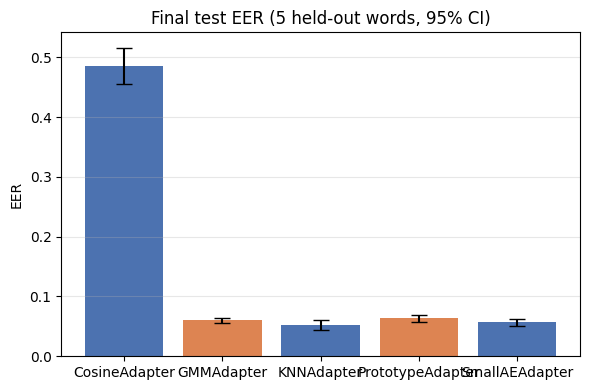

In [321]:
from scipy import stats as _stats

fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
means, margins = [], []
for a in adapters:
    vals = test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna()
    n = len(vals)
    m = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    means.append(m)
    margins.append(t_crit * sem)

ax.bar(adapters, means, yerr=margins, capsize=6, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("EER")
ax.set_title("Final test EER (5 held-out words, 95% CI)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Paired t-test: GMM vs AE on EER

In [322]:
idx = ["p_trial", "p_target_class"]
# Multiple GMM configs / train_n per (trial, target) -> mean within adapter first.
gmm_eer = test_df[test_df["p_adapter"] == "GMMAdapter"].groupby(idx)["m_eer"].mean()
ae_eer  = test_df[test_df["p_adapter"] == "SmallAEAdapter"].groupby(idx)["m_eer"].mean()
paired = pd.concat([gmm_eer.rename("gmm"), ae_eer.rename("ae")], axis=1).dropna()
diff = paired["ae"] - paired["gmm"]
t, p = _stats.ttest_rel(paired["ae"], paired["gmm"])
cohen_d = diff.mean() / diff.std(ddof=1)
print(f"n={len(paired)}  mean(AE-GMM)={diff.mean():+.4f}  cohen_d={cohen_d:+.3f}  t={t:+.3f}  p={p:.4g}")

ValueError: cannot handle a non-unique multi-index!

## EER distribution (boxplot)

Distribution across all 5 target words x 10 trials = 50 runs per adapter.

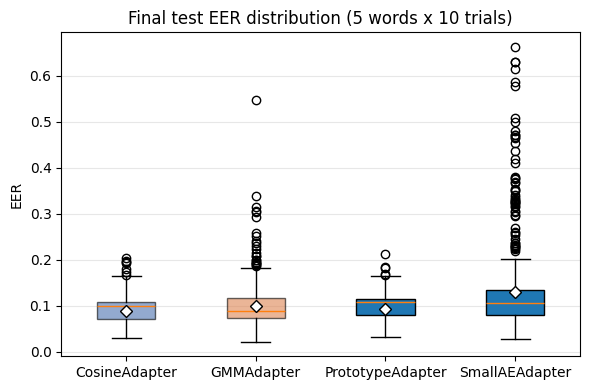

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
data = [test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna().values for a in adapters]
bp = ax.boxplot(data, tick_labels=adapters, patch_artist=True, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"})
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("EER")
ax.set_title("Final test EER distribution (5 words x 10 trials)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## FAR vs Recall scatter

One point per (trial, target_word) — shows operating-point calibration spread.

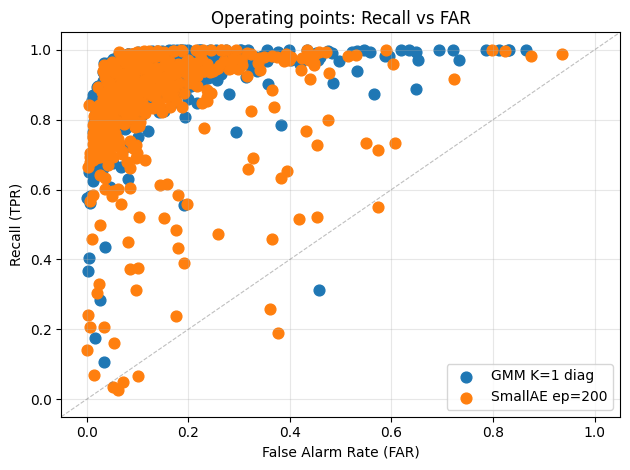

In [ ]:
from compare.plots import plot_far_recall

test_lines = [
    ("GMM K=1 diag",   {"p_adapter": "GMMAdapter"}),
    ("SmallAE ep=200", {"p_adapter": "SmallAEAdapter"}),
]
plot_far_recall(test_df, lines=test_lines)
plt.show()